# Limpieza Tablas 

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

## Cargando Tablas

In [23]:
calendar = pd.read_csv("../data/calendar.csv")
sales_evaluation = pd.read_csv("../data/sales_train_evaluation.csv")
sales_validation = pd.read_csv("../data/sales_train_validation.csv")
sample_submission = pd.read_csv("../data/sample_submission.csv")
sell_prices = pd.read_csv("../data/sell_prices.csv")

## Limpieza de Tabla Calendar 

In [24]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [25]:
# nulos y duplicados
calendar.isnull().sum()
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [26]:
# Cambiando de tipo de dato date
calendar['date'] = pd.to_datetime(calendar['date'])

In [27]:
# Reemplazo NaN en eventos por "None", porque esos Nan significan que no paso nada 
columns = ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']

for name in columns:
    calendar[name] = calendar[name].fillna("None")


In [28]:
#Creamos una variable binaria para saber si hubo un evento ese dia 

calendar['has_event'] = ((calendar['event_name_1'] != None) | (calendar['event_name_2'] != None).astype(int))

In [29]:
calendar

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,has_event
0,2011-01-29,11101,Saturday,1,1,2011,d_1,None,None,None,None,0,0,0,True
1,2011-01-30,11101,Sunday,2,1,2011,d_2,None,None,None,None,0,0,0,True
2,2011-01-31,11101,Monday,3,1,2011,d_3,None,None,None,None,0,0,0,True
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,None,None,None,None,1,1,0,True
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,None,None,None,None,1,0,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,None,None,None,None,0,1,1,True
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,None,None,None,None,0,0,0,True
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,None,None,None,None,0,0,0,True
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,None,None,None,None,0,0,0,True


## sales_train_validation

In [30]:
## Voy a filtrar por 'store_id' == 'CA_1' para crear un prototipo porque serian de mas filas y seria
# el primer vistazo a los datos 
sales_small = sales_validation[sales_validation['store_id'] == 'CA_1']

In [31]:
sales_small.shape

(3049, 1919)

In [32]:
# Para poder hacer el merge entre sales_Validation y calendar, tengo que pasar de formato de ancho a largo
# a la tabla sales_validation

sales_long = sales_small.melt(
    id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], 
    var_name = "d", 
    value_name = "sales")


In [33]:
sales_long

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
...,...,...,...,...,...,...,...,...
5832732,FOODS_3_823_CA_1_validation,FOODS_3_823,FOODS_3,FOODS,CA_1,CA,d_1913,1
5832733,FOODS_3_824_CA_1_validation,FOODS_3_824,FOODS_3,FOODS,CA_1,CA,d_1913,0
5832734,FOODS_3_825_CA_1_validation,FOODS_3_825,FOODS_3,FOODS,CA_1,CA,d_1913,2
5832735,FOODS_3_826_CA_1_validation,FOODS_3_826,FOODS_3,FOODS,CA_1,CA,d_1913,0


### Revisando los nuevos valores de la tabla sales_long 

In [34]:
sales_long["sales"].describe()

count    5.832737e+06
mean     1.319829e+00
std      4.058652e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      6.480000e+02
Name: sales, dtype: float64

La mediana es 0 -> el 50% de las observaciones tienen ventas = 0. Muchos días sin venta por producto.\
La media es 1.32 -> promedio muy bajo, indica que la mayoria de productos venden poco por día.\
Alta desviación estándar \
std= 4.05 con media de 1.32 -> alta variabilidad, distribución muy sesgada\
Maximo = 648 existen picos grandes de ventas\
probablemente: promociones, eventos, productos populares.

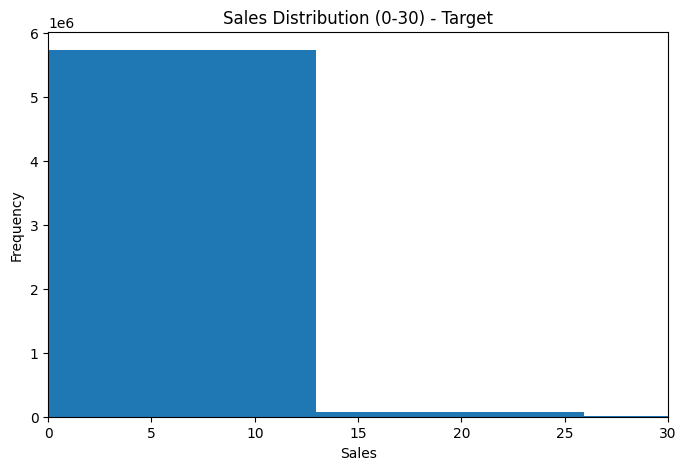

In [35]:
plt.figure(figsize=(8,5))
plt.hist(sales_long["sales"], bins=50)
plt.title("Sales Distribution (0-30) - Target")
plt.xlim(0,30)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

Este target puede requerir transformación mas adelante

In [36]:
(sales_long["sales"] == 0).mean() 
# porcentaje de dias sin venta

0.6394733724493321

In [37]:
calendar_sales = sales_long.merge(calendar, on='d', how='left')

In [38]:
calendar_sales

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,has_event
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,None,None,None,None,0,0,0,True
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,None,None,None,None,0,0,0,True
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,None,None,None,None,0,0,0,True
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,None,None,None,None,0,0,0,True
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,None,None,None,None,0,0,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5832732,FOODS_3_823_CA_1_validation,FOODS_3_823,FOODS_3,FOODS,CA_1,CA,d_1913,1,2016-04-24,11613,...,4,2016,None,None,None,None,0,0,0,True
5832733,FOODS_3_824_CA_1_validation,FOODS_3_824,FOODS_3,FOODS,CA_1,CA,d_1913,0,2016-04-24,11613,...,4,2016,None,None,None,None,0,0,0,True
5832734,FOODS_3_825_CA_1_validation,FOODS_3_825,FOODS_3,FOODS,CA_1,CA,d_1913,2,2016-04-24,11613,...,4,2016,None,None,None,None,0,0,0,True
5832735,FOODS_3_826_CA_1_validation,FOODS_3_826,FOODS_3,FOODS,CA_1,CA,d_1913,0,2016-04-24,11613,...,4,2016,None,None,None,None,0,0,0,True


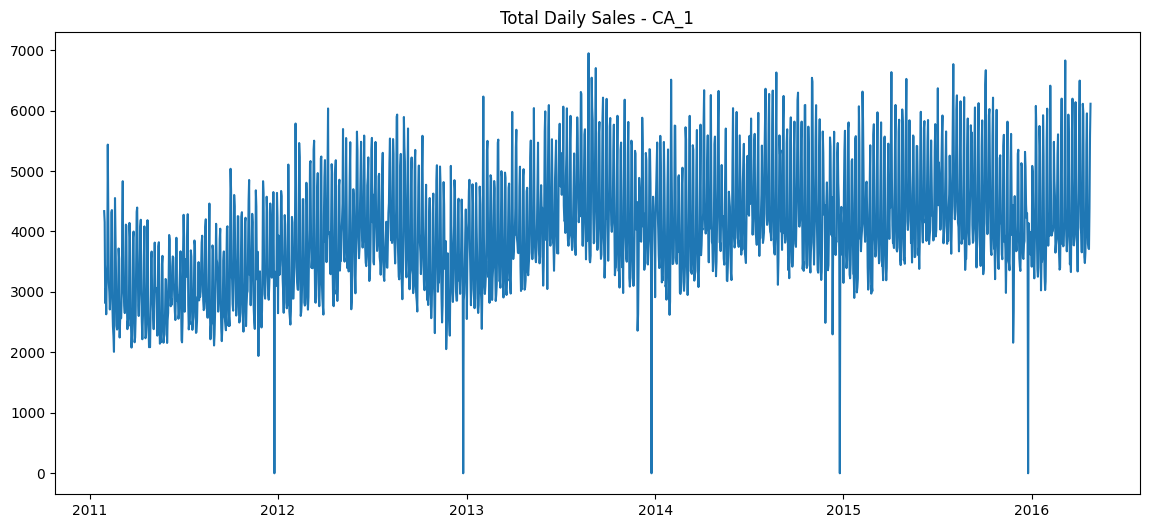

In [39]:
# Ventas totales por dia 
daily_sales = calendar_sales.groupby("date")['sales'].sum().reset_index()

plt.figure(figsize=(14,6))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Total Daily Sales - CA_1")
plt.show()

In [40]:
# viendo los dias que estan en cero en la grafica
daily_sales[daily_sales["sales"] < 500]

,date,sales
330,2011-12-25,0
696,2012-12-25,0
1061,2013-12-25,0
1426,2014-12-25,0
1791,2015-12-25,0


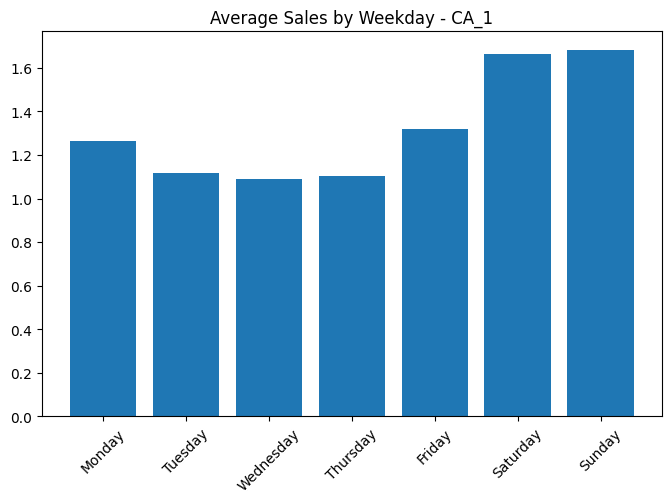

In [41]:
dow_sales = calendar_sales.groupby("weekday")["sales"].mean().reset_index()

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_sales["weekday"] = pd.Categorical(dow_sales["weekday"], categories=order, ordered=True)
dow_sales = dow_sales.sort_values("weekday")

plt.figure(figsize=(8,5))
plt.bar(dow_sales["weekday"], dow_sales["sales"])
plt.xticks(rotation=45)
plt.title("Average Sales by Weekday - CA_1")
plt.show()

* Ventas más bajas martes-jueves
* Incremento viernes
* Pico claro sábado y domingo 

La diferencia no es enorme, pero sí consistente. 

## Revisión de sell_prices

In [47]:
sell_prices

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
...,...,...,...,...
6841116,WI_3,FOODS_3_827,11617,1.00
6841117,WI_3,FOODS_3_827,11618,1.00
6841118,WI_3,FOODS_3_827,11619,1.00
6841119,WI_3,FOODS_3_827,11620,1.00


In [46]:
df_total = calendar_sales.merge(
    sell_prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left")

In [52]:
df_total['sell_price'].isnull().sum()

1129842

In [53]:
df_total["sell_price"].isnull().mean()

0.19370700239013006

In [55]:
# ver cuando aparecen los nulos 
df_total[df_total["sell_price"].isnull()]["date"].min(), df_total[df_total["sell_price"].isnull()]["date"].max()

#los nulos aparecen desde el inicio de fecha del dataset, hasta casi el final del dataset

(Timestamp('2011-01-29 00:00:00'), Timestamp('2016-02-12 00:00:00'))

In [56]:
df_total = df_total[df_total["sell_price"].notnull()]

In [59]:
print(df_total.shape)
df_total["sell_price"].isnull().sum()

(4702895, 23)


0

In [60]:
df_total

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,has_event,sell_price
7,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_1,12,2011-01-29,11101,...,2011,None,None,None,None,0,0,0,True,0.46
8,HOBBIES_1_009_CA_1_validation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,d_1,2,2011-01-29,11101,...,2011,None,None,None,None,0,0,0,True,1.56
9,HOBBIES_1_010_CA_1_validation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,None,None,None,None,0,0,0,True,3.17
11,HOBBIES_1_012_CA_1_validation,HOBBIES_1_012,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,None,None,None,None,0,0,0,True,5.98
14,HOBBIES_1_015_CA_1_validation,HOBBIES_1_015,HOBBIES_1,HOBBIES,CA_1,CA,d_1,4,2011-01-29,11101,...,2011,None,None,None,None,0,0,0,True,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5832732,FOODS_3_823_CA_1_validation,FOODS_3_823,FOODS_3,FOODS,CA_1,CA,d_1913,1,2016-04-24,11613,...,2016,None,None,None,None,0,0,0,True,2.98
5832733,FOODS_3_824_CA_1_validation,FOODS_3_824,FOODS_3,FOODS,CA_1,CA,d_1913,0,2016-04-24,11613,...,2016,None,None,None,None,0,0,0,True,2.48
5832734,FOODS_3_825_CA_1_validation,FOODS_3_825,FOODS_3,FOODS,CA_1,CA,d_1913,2,2016-04-24,11613,...,2016,None,None,None,None,0,0,0,True,3.98
5832735,FOODS_3_826_CA_1_validation,FOODS_3_826,FOODS_3,FOODS,CA_1,CA,d_1913,0,2016-04-24,11613,...,2016,None,None,None,None,0,0,0,True,1.28


/var/folders/m_/06pskt392pn6qvkq92krm8xm0000gn/T/ipykernel_13395/3312778515.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_sales = df_total.groupby(price_bins)["sales"].mean()


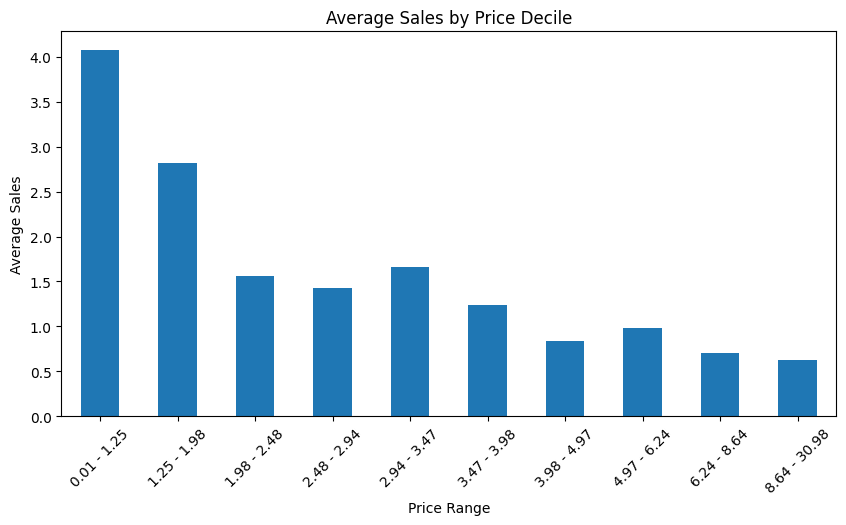

In [67]:
price_bins = pd.qcut(df_total["sell_price"], q=10)

price_sales = df_total.groupby(price_bins)["sales"].mean()

# Convertir el índice a string redondeando a 2 decimales
price_sales.index = price_sales.index.map(
    lambda x: f"{round(x.left,2)} - {round(x.right,2)}")

price_sales.plot(kind="bar", figsize=(10,5))
plt.title("Average Sales by Price Decile")
plt.xlabel("Price Range")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.show()

### Creación de lags 

In [72]:
#creando de lags
df_total = df_total.sort_values(["item_id", "date"])

df_total["lag_7"] = df_total.groupby("item_id")["sales"].shift(7)
df_total["lag_28"] = df_total.groupby("item_id")["sales"].shift(28)

In [73]:
#Rolling means 
df_total["rolling_mean_7"] = df_total.groupby("item_id")["sales"].shift(1).rolling(7).mean()
df_total["rolling_mean_28"] = df_total.groupby("item_id")["sales"].shift(1).rolling(28).mean()

In [74]:
#crear variable weekend
df_total["is_weekend"] = df_total["weekday"].isin(["Saturday","Sunday"]).astype(int)

In [75]:
df_total

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,snap_CA,snap_TX,snap_WI,has_event,sell_price,rolling_mean_7,rolling_mean_28,lag_7,lag_28,is_weekend
1612,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,0,0,0,True,2.00,NaN,NaN,NaN,NaN,1
4661,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,0,0,0,True,2.00,NaN,NaN,NaN,NaN,1
7710,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,0,0,0,True,2.00,NaN,NaN,NaN,NaN,0
10759,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,...,1,1,0,True,2.00,NaN,NaN,NaN,NaN,0
13808,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,...,1,0,1,True,2.00,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819103,HOUSEHOLD_2_516_CA_1_validation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,CA_1,CA,d_1909,0,2016-04-20,11612,...,0,0,0,True,5.94,0.285714,0.357143,0.0,1.0,0
5822152,HOUSEHOLD_2_516_CA_1_validation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,CA_1,CA,d_1910,1,2016-04-21,11612,...,0,0,0,True,5.94,0.285714,0.321429,1.0,0.0,0
5825201,HOUSEHOLD_2_516_CA_1_validation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,CA_1,CA,d_1911,1,2016-04-22,11612,...,0,0,0,True,5.94,0.285714,0.357143,1.0,0.0,0
5828250,HOUSEHOLD_2_516_CA_1_validation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,CA_1,CA,d_1912,0,2016-04-23,11613,...,0,0,0,True,5.94,0.285714,0.392857,0.0,0.0,1


In [76]:
df = df_total.dropna()

In [77]:
df.shape

(4617523, 28)

In [84]:
features = ["sell_price", "lag_7", "lag_28", "rolling_mean_7", "rolling_mean_28", "is_weekend", "month"]
target = df["sales"]

In [85]:
#Haciendo Split temporal 

train = df[df["date"] < "2016-01-01"]
test = df[df["date"] >= '2016-01-01']

In [86]:
X_train = train[features]
y_train = train['sales']

X_test = test[features]
y_test = test['sales']

In [87]:
model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1)
model.fit(X_train, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
